In [1]:
import tensorflow as tf
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available: 1


In [2]:
import tensorflow as tf
tf.keras.backend.clear_session()

import gc
gc.collect()


0

**Connecting to google drive to get dataset.**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!cp -r "/content/drive/MyDrive/Vegetable Images" /content/

**Step- Data Collection and Data Analysis**

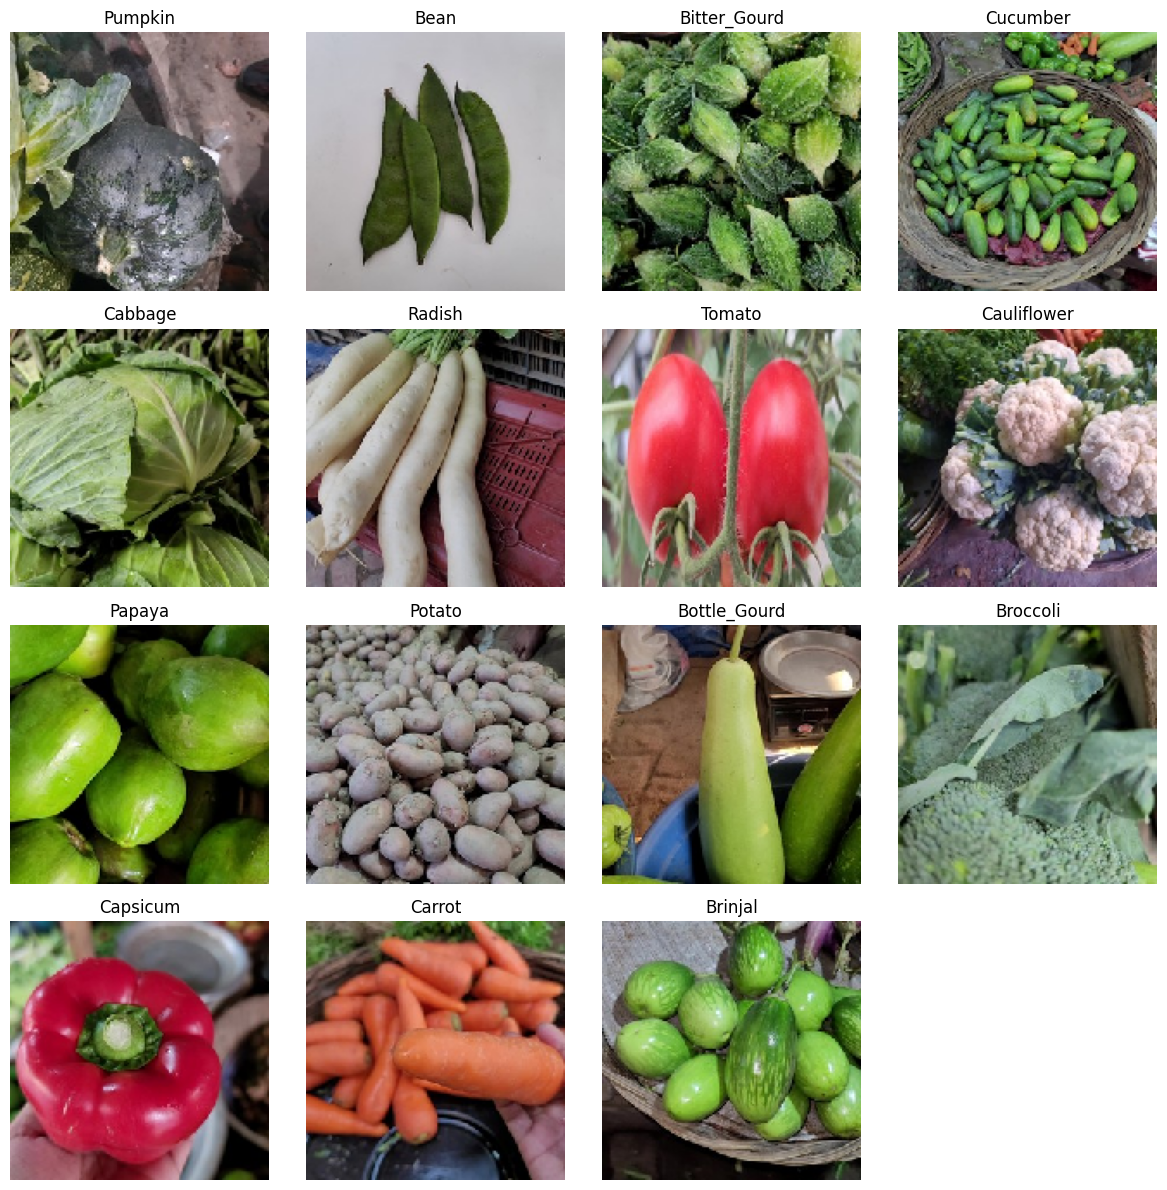

In [5]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
#Define Datasets paths
train_path = "/content/Vegetable Images/train"
validation_path = "/content/Vegetable Images/validation"
test_path = "/content/Vegetable Images/test"

#Get categories names
image_categories = os.listdir('/content/Vegetable Images/train')
#Define a Function to Plot Images
def plot_images(image_categories):

    plt.figure(figsize=(12, 12))

    for i, cat in enumerate(image_categories):

        # Load image
        image_path = train_path + '/' + cat
        images_in_folder = os.listdir(image_path)
        first_image_of_folder = images_in_folder[0]
        first_image_path = image_path + '/' + first_image_of_folder

        img = tf.keras.utils.load_img(first_image_path, target_size=(150,150))
        img_arr = tf.keras.utils.img_to_array(img) / 255.0

        # Display image
        plt.subplot(4, 4, i+1)   # adjust grid if needed
        plt.imshow(img_arr)
        plt.title(cat)
        plt.axis('off')

    plt.tight_layout()
    plt.show()
plot_images(image_categories)

**Step - Pre-Processing**

In [6]:
batch_size = 32
img_height = 150
img_width = 150

# Create data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

validation_test_datagen = ImageDataGenerator(rescale=1./255)

# Flow images from directories
train_image_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

val_image_generator = validation_test_datagen.flow_from_directory(
    validation_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical'
)

test_image_generator = validation_test_datagen.flow_from_directory(
    test_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(f"Number of training samples: {train_image_generator.samples}")
print(f"Number of validation samples: {val_image_generator.samples}")
print(f"Number of test samples: {test_image_generator.samples}")
print(f"Number of classes: {train_image_generator.num_classes}")

Found 15000 images belonging to 15 classes.
Found 3014 images belonging to 15 classes.
Found 3000 images belonging to 15 classes.
Number of training samples: 15000
Number of validation samples: 3014
Number of test samples: 3000
Number of classes: 15


**Step -Model Building**

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input

model = Sequential()

# Add Input layer first
model.add(Input(shape=(150,150,3)))

# First Conv Layer
model.add(Conv2D(32, 3, strides=1, padding='same', activation='relu'))
model.add(MaxPooling2D(2))

# Second Conv Layer
model.add(Conv2D(64, 3, strides=1, padding='same', activation='relu'))
model.add(MaxPooling2D(2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(128, activation='relu'))

# Output
model.add(Dense(15, activation='softmax'))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 87616)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,214,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,252,815 (42.93 MB)

 Trainable params: 11,252,815 (42.93 MB)

 Non-trainable params: 0 (0.00 B)

**step - Compile Model**

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

**Step -Train Model**

In [9]:
history = model.fit(
    train_image_generator,
    epochs=100,
    validation_data=val_image_generator,
    steps_per_epoch=train_image_generator.samples // train_image_generator.batch_size,
    validation_steps=val_image_generator.samples // val_image_generator.batch_size,
    callbacks=[early_stopping,checkpoint],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step - accuracy: 0.2985 - loss: 2.1358
Epoch 1: val_loss improved from inf to 0.93534, saving model to best_model.keras
468/468 ━━━━━━━━━━━━━━━━━━━━ 111s 219ms/step - accuracy: 0.2988 - loss: 2.1348 - val_accuracy: 0.6948 - val_loss: 0.9353
Epoch 2/100
  1/468 ━━━━━━━━━━━━━━━━━━━━ 18s 39ms/step - accuracy: 0.6250 - loss: 1.2516

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.93534 to 0.90648, saving model to best_model.keras
468/468 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.6250 - loss: 1.2516 - val_accuracy: 0.7025 - val_loss: 0.9065
Epoch 3/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.6646 - loss: 0.9983
Epoch 3: val_loss improved from 0.90648 to 0.50896, saving model to best_model.keras
468/468 ━━━━━━━━━━━━━━━━━━━━ 142s 303ms/step - accuracy: 0.6646 - loss: 0.9982 - val_accuracy: 0.8348 - val_loss: 0.5090
Epoch 4/100
  1/468 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 0.8750 - loss: 0.5007
Epoch 4: val_loss did not improve from 0.50896
468/468 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8750 - loss: 0.5007 - val_accuracy: 0.8351 - val_loss: 0.5121
Epoch 5/100
468/468 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.7400 - loss: 0.7731
Epoch 5: val_loss improved from 0.50896 to 0.40067, saving model to best_model.keras
468/468 ━━━━━━━━━━━━━━━━━━━━ 93s 200ms/step - accuracy: 0.7401 - loss: 0.77

**Step- Plot Accuracy & Loss**

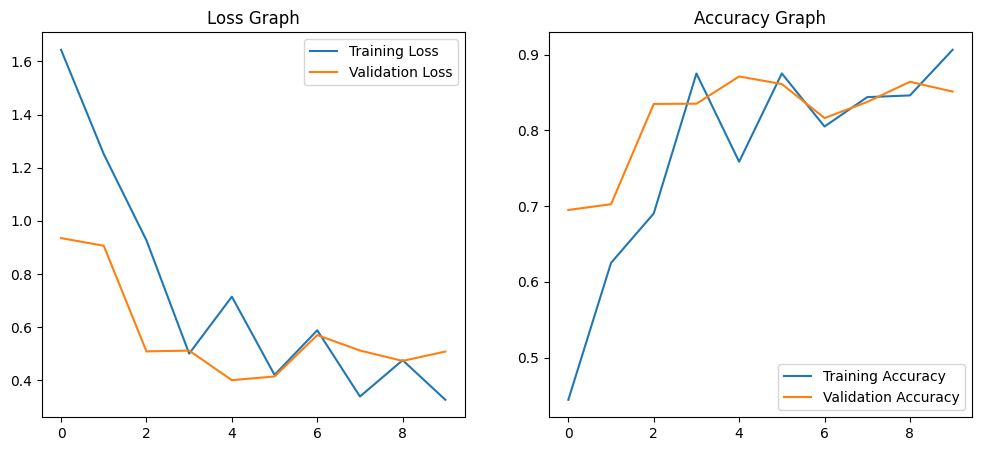

In [10]:
import matplotlib.pyplot as plt

h = history.history

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(h['loss'], label='Training Loss')
plt.plot(h['val_loss'], label='Validation Loss')
plt.title('Loss Graph')
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(h['accuracy'], label='Training Accuracy')
plt.plot(h['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Graph')
plt.legend()

plt.show()


**step -Evaluate on Test Set**

In [11]:
test_loss, test_accuracy = model.evaluate(test_image_generator)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


94/94 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.8515 - loss: 0.4517
Test Loss: 0.40214115381240845
Test Accuracy: 0.8786666393280029


**Step-Predict on Single Image(Inference)**

Updated Bean image path to: /content/Vegetable Images/test/Bean/0010.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 699ms/step


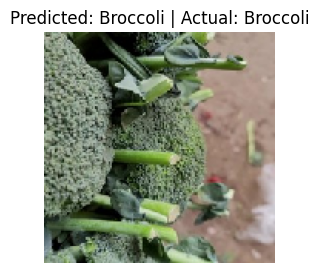

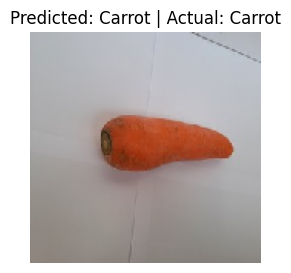

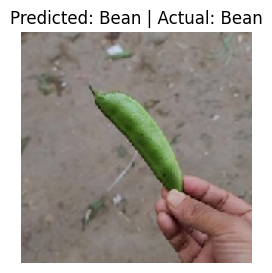

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os

def generate_multiple_predictions(image_paths, actual_labels):

    batch_images = []

    # 1‶ Load and preprocess all images
    for path in image_paths:
        img = tf.keras.utils.load_img(path, target_size=(150,150))
        img_array = tf.keras.utils.img_to_array(img) / 255.0
        batch_images.append(img_array)

    # Convert list to numpy array (batch)
    batch_images = np.array(batch_images)

    # 2‶ Predict all at once
    predictions = model.predict(batch_images)

    # 3‶ Process each prediction
    for i in range(len(image_paths)):
        predicted_index = np.argmax(predictions[i])
        predicted_label = class_map[predicted_index]

        plt.figure(figsize=(3,3))
        plt.imshow(batch_images[i])
        plt.title(f"Predicted: {predicted_label} | Actual: {actual_labels[i]}")
        plt.axis('off')
        plt.show()

# Define class_map using the class_indices from the training generator
class_map = {v: k for k, v in train_image_generator.class_indices.items()}

image_paths = [
    '/content/Vegetable Images/test/Broccoli/1011.jpg',
    '/content/Vegetable Images/test/Carrot/1022.jpg',
    '/content/Vegetable Images/test/Bean/1050.jpg'
]

actual_labels = ['Broccoli', 'Carrot', 'Bean']

# Dynamically find a valid image path for 'Bean' if the original is not found
bean_test_dir = os.path.join(test_path, 'Bean')
if not os.path.exists(image_paths[2]) and os.path.exists(bean_test_dir):
    bean_images = os.listdir(bean_test_dir)
    if bean_images:
        # Use the first image found in the Bean test directory
        image_paths[2] = os.path.join(bean_test_dir, bean_images[0])
        print(f"Updated Bean image path to: {image_paths[2]}")
    else:
        print(f"No images found in the '{bean_test_dir}' directory. Please check the dataset.")
elif not os.path.exists(bean_test_dir):
    print(f"Directory '{bean_test_dir}' not found. Please check the dataset path.")

generate_multiple_predictions(image_paths, actual_labels)
